In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [32]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [33]:
X, y_true = make_blobs(n_samples=300, centers=3,
                       cluster_std=0.60, random_state=0)
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df.head(10)

,Feature1,Feature2
0,0.428577,4.973997
1,1.619909,0.067645
2,1.432893,4.376792
3,-1.578462,3.034458
4,-1.658629,2.267460
5,-1.521727,3.234085
6,0.836857,2.136359
7,0.241009,4.810405
8,-2.103207,2.442012
9,-0.483580,3.514519


In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [35]:
#Elbow method
inertia = []
K_range = range(1,15)

In [36]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

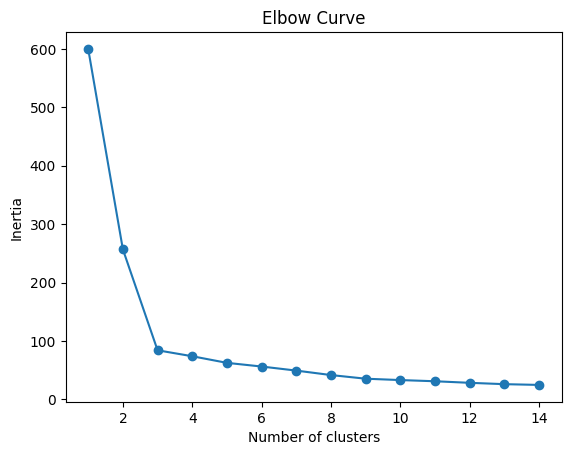

In [37]:
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

In [38]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [39]:
print(cluster_labels)

[0 2 0 1 1 1 2 0 1 1 2 2 2 0 2 1 0 0 1 2 1 0 2 0 1 1 0 1 2 2 1 0 0 2 2 1 2
 1 0 2 1 2 0 2 2 1 2 1 1 2 1 2 1 1 2 0 0 1 1 0 2 2 0 1 2 1 0 2 0 2 1 1 1 1
 2 0 2 1 0 0 1 0 2 0 0 0 2 1 0 0 1 2 1 0 2 2 0 2 1 0 2 1 0 2 0 0 1 0 2 2 0
 1 0 0 1 1 0 0 2 2 2 1 2 2 2 1 2 2 2 1 1 1 0 1 1 2 1 0 1 1 2 0 2 0 1 1 0 1
 1 2 0 1 0 2 1 1 2 2 0 2 0 0 2 0 1 0 0 0 0 1 2 0 1 2 2 2 0 2 0 0 2 1 0 0 0
 0 2 1 0 1 0 0 2 2 1 0 2 1 0 1 2 1 0 1 2 1 0 1 0 2 0 0 1 2 2 2 2 0 1 2 0 2
 2 2 0 1 1 0 0 1 0 2 2 0 2 1 1 1 0 0 2 1 1 1 1 2 1 1 0 2 2 0 2 2 1 0 2 1 0
 0 1 0 1 1 0 1 0 2 2 2 2 0 0 0 0 0 1 1 2 0 0 2 2 2 1 2 1 1 2 2 1 1 1 2 0 0
 1 2 0 1]


In [40]:
df['cluster'] = cluster_labels

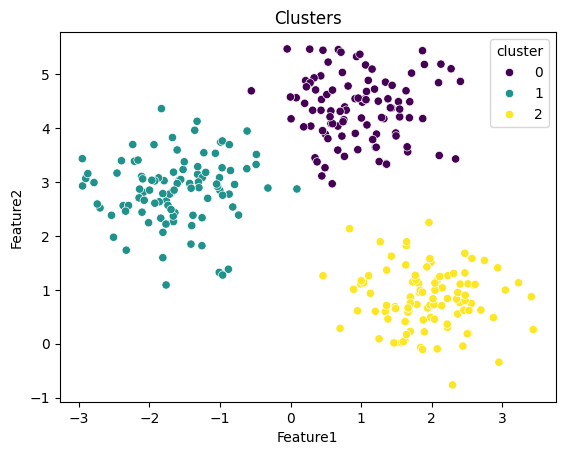

In [41]:
#Visualisation of Clusters
sns.scatterplot(x='Feature1', y='Feature2', hue=df['cluster'], data=df, palette='viridis')
plt.title('Clusters')
plt.show()

# DBScan

In [42]:
from sklearn.datasets import make_moons

In [43]:
X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df.head(10)

,Feature1,Feature2
0,-0.021371,0.406186
1,0.976700,-0.458323
2,0.904059,-0.376520
3,0.377363,-0.397037
4,-0.841926,0.530587
5,0.589303,-0.321376
6,0.292487,-0.206963
7,-0.026378,0.447663
8,1.620141,-0.287589
9,0.682467,0.807121


In [44]:
from sklearn.cluster import DBSCAN

In [45]:
X_scaled = scaler.fit_transform(df)

In [46]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [47]:
df['kmeans_clusters'] = kmeans_labels

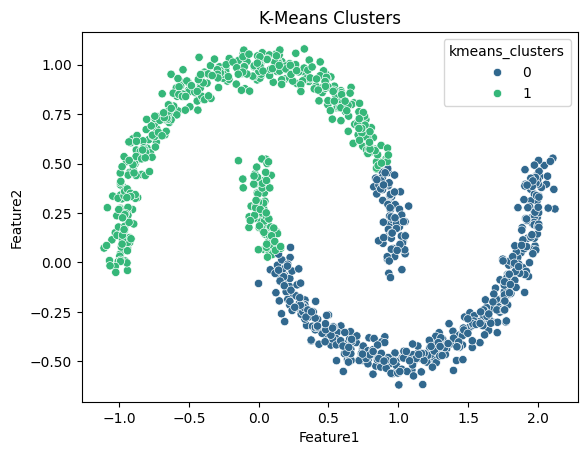

In [48]:
sns.scatterplot(x='Feature1', y='Feature2', hue=df['kmeans_clusters'], data=df, palette='viridis')
plt.title('K-Means Clusters')
plt.show()

In [49]:
dbs = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbs.fit_predict(X_scaled)

In [50]:
df['dbs_clusters'] = dbscan_labels

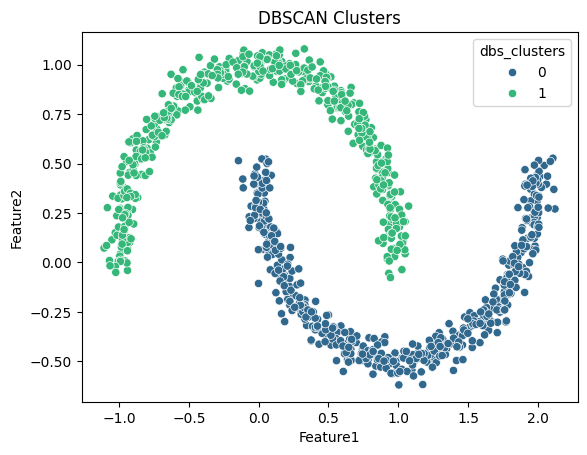

In [51]:
sns.scatterplot(x='Feature1', y='Feature2', hue=df['dbs_clusters'], data=df, palette='viridis')
plt.title('DBSCAN Clusters')
plt.show()